In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import warnings
warnings.filterwarnings('ignore')

In [2]:
movie=pd.read_csv('movie_preprocessed.csv')
movie.head()

,Unnamed: 0,budget,genres,id,keywords,original_language,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,status,tagline,title,vote_average,vote_count
0,0,15000000.0,"Action,Adventure,Fantasy,Science Fiction",19995.0,"culture clash,future,space war,space colony,so...",en,"In the 22nd century, a paraplegic Marine is di...",12.921594,"Ingenious Film Partners,Twentieth Century Fox ...","United States of America,United Kingdom",10-12-2009,19170001.0,103.0,Released,Enter the World of Pandora.,Avatar,7.2,235.0
1,1,15000000.0,"Adventure,Fantasy,Action",285.0,"ocean,drug abuse,exotic island,east india trad...",en,"Captain Barbossa, long believed to be dead, ha...",12.921594,"Walt Disney Pictures,Jerry Bruckheimer Films,S...",United States of America,19-05-2007,19170001.0,103.0,Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,235.0
2,2,15000000.0,"Action,Adventure,Crime",14629.0,"spy,based on novel,secret agent,sequel,mi6,bri...",en,A cryptic message from Bond’s past sends him o...,12.921594,"Columbia Pictures,Danjaq,B24","United Kingdom,United States of America",26-10-2015,19170001.0,148.0,Released,A Plan No One Escapes,Spectre,6.3,235.0
3,3,15000000.0,"Action,Crime,Drama,Thriller",49026.0,"dc comics,crime fighter,terrorist,secret ident...",en,Following the death of District Attorney Harve...,12.921594,"Legendary Pictures,Warner Bros,DC Entertainmen...",United States of America,16-07-2012,19170001.0,103.0,Released,The Legend Ends,The Dark Knight Rises,7.6,235.0
4,4,15000000.0,"Action,Adventure,Science Fiction",49529.0,"based on novel,mars,medallion,space travel,pri...",en,"John Carter is a war-weary, former military ca...",43.926995,Walt Disney Pictures,United States of America,07-03-2012,19170001.0,132.0,Released,"Lost in our world, found in another.",John Carter,6.1,235.0


In [3]:
movie.drop(columns=['Unnamed: 0'], inplace=True)


In [4]:
credit=pd.read_csv('credit_preprocessed.csv')
credit.head()

,Unnamed: 0,movie_id,title,cast,director,editor,production_design,art_direction,costume_design,original_music_composer,director_of_photography
0,0,19995,Avatar,"Sam Worthington,Zoe Saldana,Sigourney Weaver,S...",James Cameron,Stephen E. Rivkin,Rick Carter,Andrew Menzies,Deborah Lynn Scott,James Horner,Mauro Fiore
1,1,285,Pirates of the Caribbean At Worlds End,"Johnny Depp,Orlando Bloom,Keira Knightley,Stel...",Gore Verbinski,Stephen E. Rivkin,Rick Heinrichs,John Dexter,Liz Dann,Hans Zimmer,Dariusz Wolski
2,2,206647,Spectre,"Daniel Craig,Christoph Waltz,Léa Seydoux,Ralph...",Sam Mendes,Lee Smith,Dennis Gassner,Neal Callow,Jany Temime,Thomas Newman,Hoyte van Hoytema
3,3,49026,The Dark Knight Rises,"Christian Bale,Michael Caine,Gary Oldman,Anne ...",Christopher Nolan,Lee Smith,Nathan Crowley,Robert Woodruff,Lindy Hemming,Hans Zimmer,Wally Pfister
4,4,49529,John Carter,"Taylor Kitsch,Lynn Collins,Samantha Morton,Wil...",Andrew Stanton,Eric Zumbrunnen,Nathan Crowley,Robert Woodruff,Mayes C. Rubeo,Unknown,Daniel Mindel


In [5]:
credit.drop(columns=['Unnamed: 0'], inplace=True)

In [6]:
df=pd.read_csv('joined_dataset.csv')
df.head()

,Unnamed: 0,budget,genres,id,keywords,original_language,overview,popularity,production_companies,production_countries,...,vote_count,movie_id,cast,director,editor,production_design,art_direction,costume_design,original_music_composer,director_of_photography
0,0,15000000.0,"Action,Adventure,Fantasy,Science Fiction",19995.0,"culture clash,future,space war,space colony,so...",en,"In the 22nd century, a paraplegic Marine is di...",12.921594,"Ingenious Film Partners,Twentieth Century Fox ...","United States of America,United Kingdom",...,235.0,19995,"Sam Worthington,Zoe Saldana,Sigourney Weaver,S...",James Cameron,Stephen E. Rivkin,Rick Carter,Andrew Menzies,Deborah Lynn Scott,James Horner,Mauro Fiore
1,1,15000000.0,"Action,Adventure,Crime",14629.0,"spy,based on novel,secret agent,sequel,mi6,bri...",en,A cryptic message from Bond’s past sends him o...,12.921594,"Columbia Pictures,Danjaq,B24","United Kingdom,United States of America",...,235.0,206647,"Daniel Craig,Christoph Waltz,Léa Seydoux,Ralph...",Sam Mendes,Lee Smith,Dennis Gassner,Neal Callow,Jany Temime,Thomas Newman,Hoyte van Hoytema
2,2,15000000.0,"Action,Crime,Drama,Thriller",49026.0,"dc comics,crime fighter,terrorist,secret ident...",en,Following the death of District Attorney Harve...,12.921594,"Legendary Pictures,Warner Bros,DC Entertainmen...",United States of America,...,235.0,49026,"Christian Bale,Michael Caine,Gary Oldman,Anne ...",Christopher Nolan,Lee Smith,Nathan Crowley,Robert Woodruff,Lindy Hemming,Hans Zimmer,Wally Pfister
3,3,15000000.0,"Action,Adventure,Science Fiction",49529.0,"based on novel,mars,medallion,space travel,pri...",en,"John Carter is a war-weary, former military ca...",43.926995,Walt Disney Pictures,United States of America,...,235.0,49529,"Taylor Kitsch,Lynn Collins,Samantha Morton,Wil...",Andrew Stanton,Eric Zumbrunnen,Nathan Crowley,Robert Woodruff,Mayes C. Rubeo,Unknown,Daniel Mindel
4,4,15000000.0,"Animation,Family",38757.0,"hostage,magic,horse,fairy tale,musical,princes...",en,When the kingdom's most wanted-and most charmi...,48.681969,"Walt Disney Pictures,Walt Disney Animation Stu...",United States of America,...,235.0,38757,"Zachary Levi,Mandy Moore,Donna Murphy,Ron Perl...",Byron Howard,Tim Mertens,Douglas Rogers,David Goetz,Unknown,Alan Menken,Unknown


In [7]:
df.drop(columns=['Unnamed: 0'], inplace=True)

# Which director relased most movies

In [8]:
credit_values = credit[credit['director'] != 'Unknown']['director'].value_counts()
top_director = credit_values.idxmax()
top_count = credit_values.max()
print("Most frequent director:", top_director)
print("Number of movies:", top_count)

Most frequent director: Steven Spielberg
Number of movies: 27


# Which director got highest revenue

In [9]:
director_revenue = df.groupby('director')['revenue'].sum().sort_values(ascending=False)
top_director = director_revenue.idxmax()
top_revenue = director_revenue.max()
top_movie_count = df[df['director'] == top_director].shape[0]
print("Director with highest total revenue:", top_director)
print("Total revenue:", top_revenue)
print("Total movies:", top_movie_count)


Director with highest total revenue: Clint Eastwood
Total revenue: 1653527209.0
Total movies: 19


# Most profitable director actor combo

In [10]:
df['profit'] = df['revenue'] - df['budget']
df['cast'] = df['cast'].fillna('').astype(str).str.split(',')
credit_exploded = df.explode('cast').reset_index(drop=True).copy()
director_actor_profit = (credit_exploded.groupby(['director', 'cast'])['profit'].sum().sort_values(ascending=False))
if not director_actor_profit.empty:
    top_pair = director_actor_profit.idxmax()
    top_profit = director_actor_profit.max()
    print("Most profitable director-actor pair:", top_pair)
    print("Total profit:", top_profit)
    print("\nTop 10 director-actor pairs by total profit:\n")
    print(director_actor_profit.head(10))
else:
    print("No director-actor profit data available.")



Most profitable director-actor pair: ('John Glen', 'Desmond Llewelyn')
Total profit: 725093674.0

Top 10 director-actor pairs by total profit:

director        cast            
John Glen       Desmond Llewelyn    725093674.0
Paul Feig       Chaunty Spillane    642442527.0
Clint Eastwood  Clint Eastwood      620557582.0
John Glen       Walter Gotell       600926659.0
                Geoffrey Keen       600926659.0
                Robert Brown        557780872.0
Wes Craven      Neve Campbell       486382926.0
                Roger L Jackson     486382926.0
                Courteney Cox       486382926.0
                David Arquette      486382926.0
Name: profit, dtype: float64


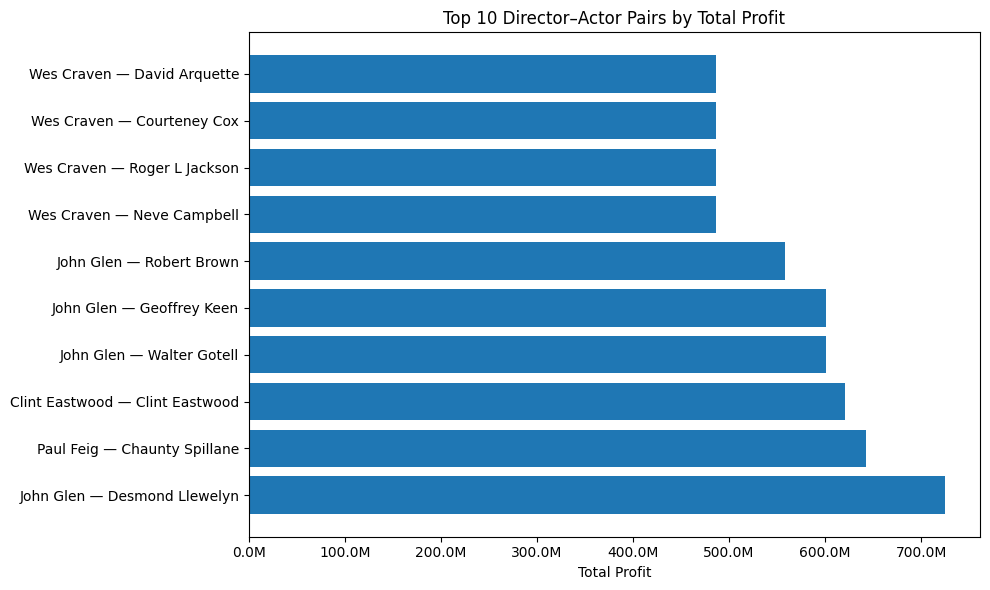

In [11]:
import matplotlib.ticker as mtick
dap_df = director_actor_profit.reset_index()
dap_df.columns = ['director', 'actor', 'total_profit']
top10 = dap_df.head(10)
plt.figure(figsize=(10,6))

plt.barh(top10['director'] + " — " + top10['actor'], top10['total_profit'])
plt.xlabel('Total Profit')
plt.title('Top 10 Director–Actor Pairs by Total Profit')
ax = plt.gca()
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
plt.tight_layout()
plt.show()


# Director actor combo with highest vote 

In [12]:
df['cast'] = df['cast'].fillna('').astype(str).str.split(',')
credit_exploded = df.explode('cast').reset_index(drop=True).copy()
director_actor_profit = (credit_exploded.groupby(['director', 'cast'])['vote_average'].max().sort_values(ascending=False))
if not director_actor_profit.empty:
    print("\nTop 10 director-actor pairs by vote_average:\n")
    print(director_actor_profit.head(10))
else:
    print("No director-actor  data available.")


Top 10 director-actor pairs by vote_average:

director        cast              
Frank Darabont  'David Proval'        8.5
                'Jeffrey DeMunn'      8.5
                'James Whitmore'      8.5
                'James Babson'        8.5
                'Philip Ettington'    8.5
                'Clancy Brown'        8.5
                'Brian Libby'         8.5
                'Brian Delate'        8.5
                'Brian Brophy'        8.5
                'Gary Lee Davis'      8.5
Name: vote_average, dtype: float64


# Who is the most profitable director

In [14]:
director_profit = df.groupby(['director'])['profit'].sum().sort_values(ascending=False)
top_director =director_profit.idxmax()
top_profit =director_profit.max()
print("Director with highest profit:", top_director)
print("Total profit: $",top_profit)

Director with highest profit: Clint Eastwood
Total profit: $ 931227209.0


Top 5 Most Profitable Directors (in Million ):
director
Clint Eastwood     931.23
Oliver Stone       770.29
John Glen          725.09
Ivan Reitman       684.48
Martin Scorsese    560.89
Name: profit, dtype: float64




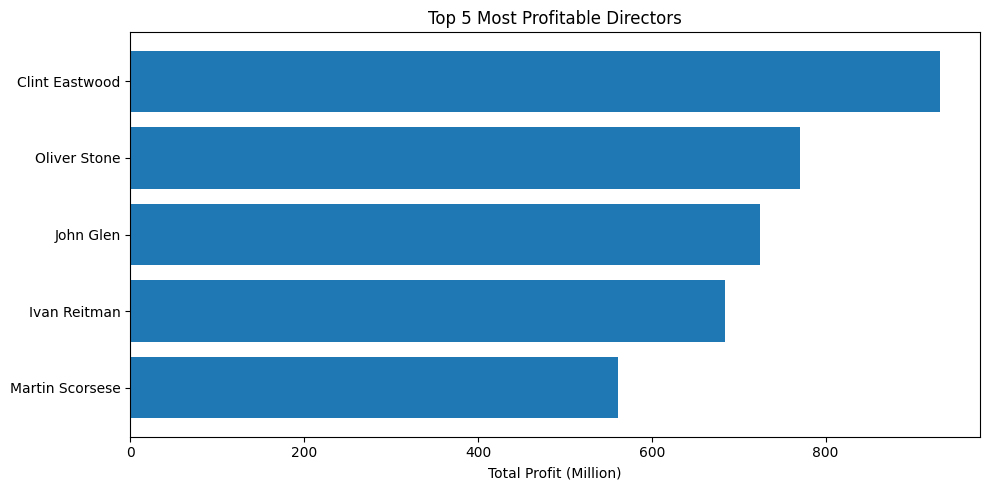

In [15]:
top_5_directors = director_profit.head(5)
top_5_directors_million = (top_5_directors / 1e6).round(2)
print("Top 5 Most Profitable Directors (in Million ):")
print(top_5_directors_million)
print("\n")

plt.figure(figsize=(10,5))
bars = plt.barh(top_5_directors_million.index, top_5_directors_million.values)
plt.title("Top 5 Most Profitable Directors")
plt.xlabel("Total Profit (Million)")
ax = plt.gca()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


# Which music composer genrate high revenue to the movie

In [16]:
composer_profit = df.groupby('original_music_composer')['profit'].sum().sort_values(ascending=False)
composer_profit = composer_profit[composer_profit.index.str.lower() != 'unknown']
top_composer = composer_profit.idxmax()
top_profit = composer_profit.max()
print("Music composer with highest profit:", top_composer)
print("Total profit: $", round(top_profit, 2))


Music composer with highest profit: John Barry
Total profit: $ 1410989260.0
